In [4]:
import numpy as np

In [1]:
from find_deps import (
    build_dependency_graph,
    build_adjacency_matrix,
    populate_dot_graph
)

In [2]:
labels, edges = build_dependency_graph(['stdio.h'])

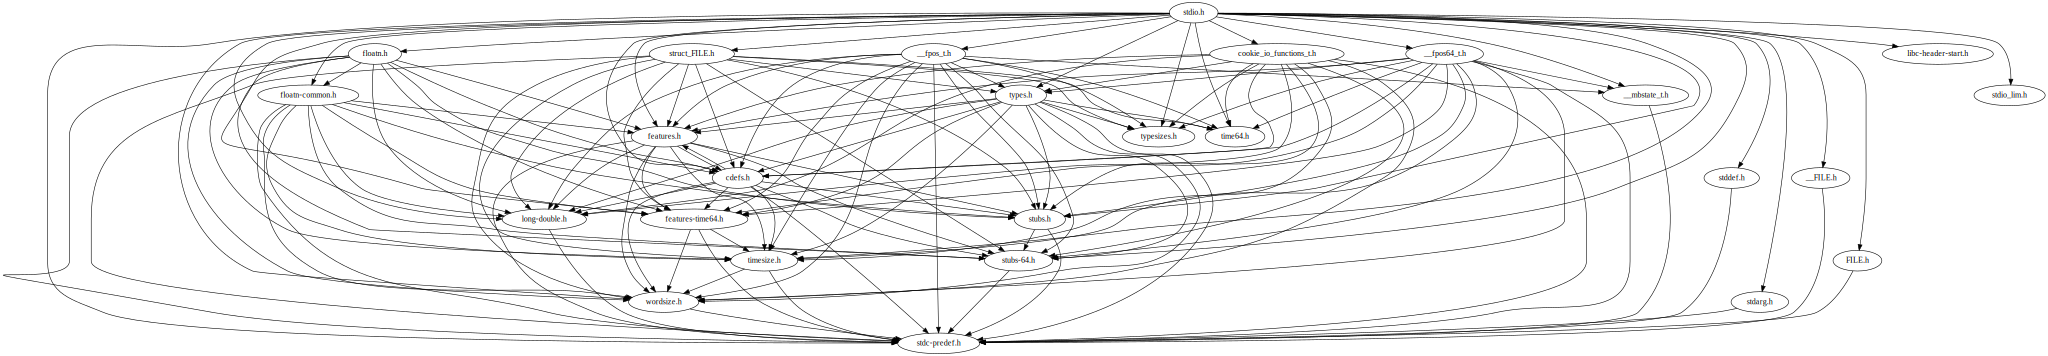

In [3]:
populate_dot_graph(labels, edges)

## Transitive closure
The relation is already transitive by construction

In [6]:
def compute_transitive_closure(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    closure = A.copy()
    for k in range(n):
        for i in range(n):
            for j in range(n):
                closure[i, j] = closure[i, j] or (closure[i, k] and closure[k, j])
    return closure

In [11]:
A = build_adjacency_matrix(labels, edges)

# we set to zero the diagonal terms of the closure
# those correspond to non trivial cycles in the graph, but we already ignore self-edges
closure = compute_transitive_closure(A)
np.fill_diagonal(closure, 0)

if np.all(closure == A):
    print("The relation is transitive")
else:
    print("The relation is not transitive")

The relation is transitive


## Hasse diagram
We want the minimal graph such that it's transitive closure is equal to A

In [12]:
def compute_hasse_diagram(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    hasse = A.copy()
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if hasse[i, j] and (hasse[i, k] and hasse[k, j]):
                    hasse[i, j] = 0
    return hasse

In [15]:
hasse = compute_hasse_diagram(A)

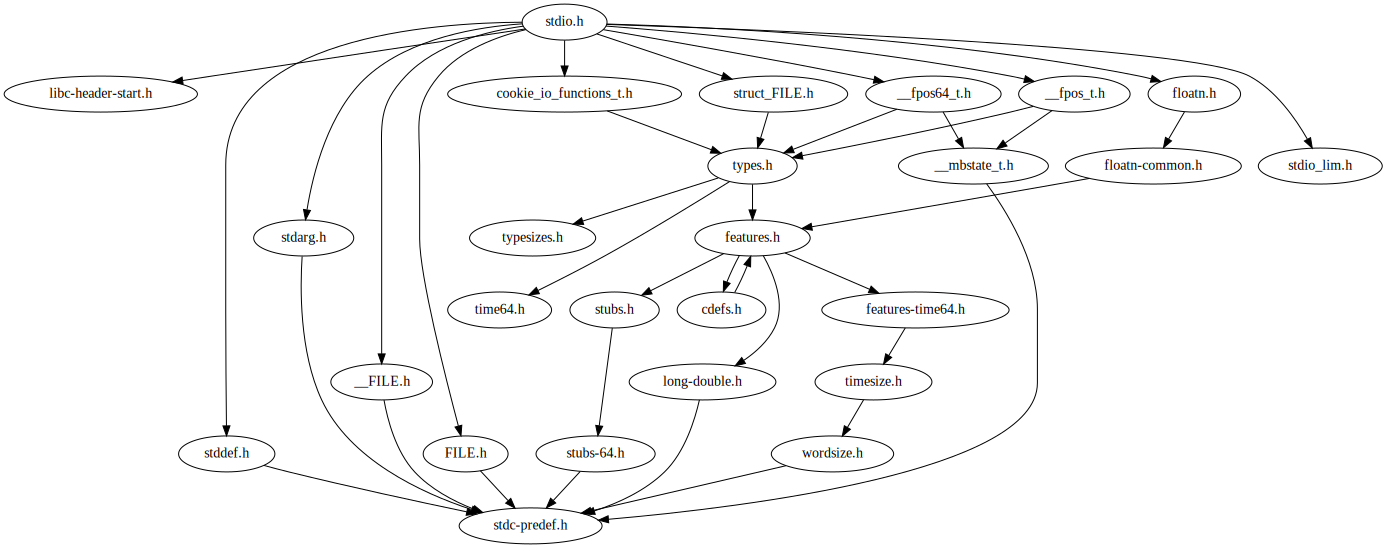

In [16]:
populate_dot_graph(labels, np.argwhere(hasse).tolist())